In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','code','BalancingControl'))

import two_stage_utils as tu
import inference as inf
import inference_utils as iu

torch threads 1
Running on device cpu
torch threads 1


In [2]:
import torch
import pyro

import os
from scipy.io import loadmat
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
import pickle
import json
import gc
import numpy as np

from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

In [44]:
results_folder = "results"
inference_folder = os.path.join(results_folder, "inference")
model_comp_folder = os.path.join(results_folder, "model_comparison")

mask_file_name = "mask.txt"
processed_data_folder = "processed_data"
mask_file = os.path.join(processed_data_folder, mask_file_name)

full_data_fname = "full_data.csv"
full_data_file = os.path.join(processed_data_folder, full_data_fname)

non_fit_fname = "non_fit_file.txt"
non_fit_file = os.path.join(model_comp_folder, non_fit_fname)

full_data_df = pd.read_csv(full_data_file)

n_agents = 188

In [4]:
trials =  201#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
# prob for invalid answer (e.g. no reply). Same frequency as in the real data
with open(mask_file, "rb") as f:
    all_mask = pickle.load(f)
# simulations will be done with the same missing actions as in the data.
exp_mask = torch.tensor(all_mask).permute((1,0))
p_valid = exp_mask.sum()/(exp_mask.shape[0]*exp_mask.shape[1])
print(p_valid)

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_valid, "mask": exp_mask}

tensor(0.9766)


/tmp/ipykernel_167234/1548601007.py:16: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  exp_mask = torch.tensor(all_mask).permute((1,0))


In [5]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

In [6]:
def convert_data_for_agent(full_data_df):

    mask = full_data_df.loc[(full_data_df["step_index"]==1)]
    mask_formatted = torch.stack([torch.from_numpy(mask.loc[mask["subject"]==i]["mask"].to_numpy()) for i in range(n_agents)])

    actions1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    actions1_formatted = torch.stack([torch.from_numpy(actions1.loc[actions1["subject"]==i]["first_stage_actions"].to_numpy()) for i in range(n_agents)])

    actions2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    actions2_formatted = torch.stack([torch.from_numpy(actions2.loc[actions2["subject"]==i]["second_stage_actions"].to_numpy()) for i in range(n_agents)])

    print("possible actions1", torch.unique(actions1_formatted[mask_formatted]))
    print("possible actions2", torch.unique(actions2_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    actions1_formatted = torch.where(mask_formatted, actions1_formatted, -1)
    actions2_formatted = torch.where(mask_formatted, actions2_formatted, -1)

    actions = torch.stack([actions1_formatted, actions2_formatted], dim=-1).permute((1,2,0))
    #print(actions.permute((0,2,1))[mask_formatted])
    # agent counts from zero:
    actions = actions-1.

    states1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    # agent counts from zero, hence -1 at the end:
    states1_formatted = torch.stack([torch.from_numpy(states1.loc[states1["subject"]==i]["first_stage_states"].to_numpy()) for i in range(n_agents)]) - 1
     
    states2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    # agent counts from zero, hence -1 at the end:
    states2_formatted = torch.stack([torch.from_numpy(states2.loc[states2["subject"]==i]["second_stage_states"].to_numpy()) for i in range(n_agents)]) - 1

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    states1_formatted = torch.where(mask_formatted, states1_formatted, -1)
    states2_formatted = torch.where(mask_formatted, states2_formatted, -1)
    # create third time step states:
    states3_formatted = states2_formatted+2 + (actions2_formatted-1)*2
    states3_formatted = torch.where(mask_formatted, states3_formatted, -1)


    print("possible states1", torch.unique(states1_formatted[mask_formatted]))
    print("possible states2", torch.unique(states2_formatted[mask_formatted]))
    print("possible states3", torch.unique(states3_formatted[mask_formatted]))

    states = torch.stack([states1_formatted, states2_formatted, states3_formatted], dim=-1).permute((1,2,0))

    # agent views r=2 as "no reward", may instead give negative reward as in Otto et al:
    rewards1_formatted = torch.zeros_like(states1_formatted) #+ 2

    rewards2_formatted = rewards1_formatted

    # create third time step rewards = second stage rewards:
    rewards3 = full_data_df.loc[(full_data_df["step_index"]==2)]
    rewards3_formatted = torch.stack([torch.from_numpy(rewards3.loc[rewards3["subject"]==i]["second_stage_rewards"].to_numpy()) for i in range(n_agents)])

    print("possible rewards1", torch.unique(rewards1_formatted[mask_formatted]))
    print("possible rewards2", torch.unique(rewards2_formatted[mask_formatted]))
    print("possible rewards3", torch.unique(rewards3_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    rewards1_formatted = torch.where(mask_formatted, rewards1_formatted, 0)
    rewards2_formatted = torch.where(mask_formatted, rewards2_formatted, 0)
    rewards3_formatted = torch.where(mask_formatted, rewards3_formatted, 0)

    rewards = torch.stack([rewards1_formatted, rewards2_formatted, rewards3_formatted], dim=-1).permute((1,2,0))


    data_dict = {"observations": states.long(), "rewards": rewards.long(), "actions": actions.long(), "valid": mask_formatted.permute((1,0))}

    return data_dict

data = convert_data_for_agent(full_data_df)

print(data)

possible actions1 tensor([1., 2.], dtype=torch.float64)
possible actions2 tensor([1., 2.], dtype=torch.float64)
possible states1 tensor([0.], dtype=torch.float64)
possible states2 tensor([1., 2.], dtype=torch.float64)
possible states3 tensor([3., 4., 5., 6.], dtype=torch.float64)
possible rewards1 tensor([0.], dtype=torch.float64)
possible rewards2 tensor([0.], dtype=torch.float64)
possible rewards3 tensor([0., 1.], dtype=torch.float64)
{'observations': tensor([[[ 0,  0,  0,  ..., -1,  0, -1],
         [ 1,  1,  2,  ..., -1,  1, -1],
         [ 3,  3,  4,  ..., -1,  5, -1]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  1,  2],
         [ 5,  3,  6,  ...,  3,  3,  4]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  2,  2,  1],
         [ 5,  3,  6,  ...,  6,  6,  3]],

        ...,

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  2,  1],
         [ 3,  5,  4,  ...,  3,  6,  3]],

        [[ 0,  0, -1,  ..., 

In [7]:
def load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names, use_h=False):    

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=False, 
                                                    use_h=use_h)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_sample_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_sample_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_sample_df

In [8]:
def load_MFMB_results(use_orig, learn_prior, use_p, restrict_alpha, max_dt, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names):    

    # set up agent
    mfmb_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, 0, base_dir, global_experiment_parameters, valid, remove_old=False)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(mfmb_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_sample_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_sample_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_sample_df

In [9]:
def calculate_log_likelihood_mean_param(data, agent, locs_df, npars, trials, T):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # this is the likelihood of the average parameter
    # answer: multiply the log by 0

    n_agents = data["actions"].shape[-1]

    log_like = torch.zeros(n_agents)
    
    # print("locs df 0", locs_df["locs"+str(0)].shape)
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    # print("resulting locs", locs.shape)
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)[0]

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))

                log_like += torch.log(masked_probs)*data["valid"][tau].long()

    return log_like
    

In [36]:
def calculate_log_likelihood_mean_param_per_choice(data, agent, locs_df, npars, trials, T):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # this is the likelihood of the average parameter
    # answer: multiply the log by 0

    n_agents = data["actions"].shape[-1]

    log_like = []
    
    # print("locs df 0", locs_df["locs"+str(0)].shape)
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    # print("resulting locs", locs.shape)
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                test = probs > 1
                if test.sum()>0:
                    print(probs)
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)[0]
                test = likes > 1
                if test.sum()>0:
                    print(likes)

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))

                test = masked_probs > 1
                if test.sum()>0:
                    print("masked", masked_probs)

                log_like.append(torch.log(masked_probs))#*data["valid"][tau].long())

                test = torch.exp(log_like[-1]) > 1
                if test.sum()>0:
                    print("log like", torch.exp(log_like[-1]))


    log_like = torch.stack(log_like, dim=0)

    test = torch.exp(log_like) > 1
    if test.sum()>0:
        print("total")

    return log_like
    

In [10]:
def calculate_lppd(data, agent, locs_df, npars, trials, T, max_samples=-1):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # Eqs (4,5) from here:
    # http://www.stat.columbia.edu/~gelman/research/published/waic_understand3.pdf
    # this is the average likelihood
    
    n_agents = data["actions"].shape[-1]
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(torch.tensor(locs_df[locs_df["subject"]==i]["locs"+str(k)].values[:max_samples]).float())
        locs_list.append(torch.stack(locs_subs, dim=-1))

    locs = torch.stack(locs_list, dim=-1)
    print("lppd locs", locs.shape)
    
    assert(locs.shape[1]==n_agents)

    #locs = torch.stack([torch.tensor(locs_df["locs"+str(i)]) for i in range(npars)], dim=-1).float()[:max_samples]

    #print("locs", locs.shape)

    n_samples = locs.shape[0]

    likelihoods = []

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                #print("probs", probs.shape)
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))
                #print("masked probs", masked_probs.shape)

                likelihoods.append(masked_probs)

                #print(tau,t)

    mean_like = torch.stack(likelihoods, dim=0)
    # print("mean like stacked", mean_like.shape)
    # print(mean_like)

    mean_like = mean_like.sum(dim=-2) / n_samples
    # print("mean like summed", mean_like.shape)
    # print(mean_like)

    mean_log_like = torch.log(mean_like).sum(dim=0)

    #print(mean_log_like)
    # print("mean log like", mean_log_like.shape)
    # print(mean_log_like)

    return mean_log_like
    

In [11]:
def predictive_accuracy_mean_param(data, agent, locs_df, npars, trials, T):

    n_agents = data["actions"].shape[-1]

    predicted_accuracy = torch.zeros(n_agents)
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    num_valid_responses = torch.zeros(data["actions"].shape[-1])

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:
                #print(tau,t)

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]#*data["valid"][tau].long()
                #print(curr_response)

                predicted_response = torch.argmax(probs, dim=0)[0]

                #print(probs)

                #print(predicted_response)

                correct_response_predicted = (curr_response == predicted_response).int()

                #print(correct_response_predicted)

                predicted_accuracy += correct_response_predicted

                num_valid_responses += data["valid"][tau]

                #print(num_valid_responses)


    corrected_predicted_accuracy = predicted_accuracy / num_valid_responses

    return corrected_predicted_accuracy

In [12]:
def calculate_avg_likelihood_mean_param(data, agent, locs_df, npars, trials, T):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # this is the likelihood of the average parameter
    
    n_agents = data["actions"].shape[-1]

    like = torch.zeros(n_agents)
    log_like = torch.zeros(n_agents)
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    num_valid_responses = torch.zeros(data["actions"].shape[-1])

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)[0]

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.0]))

                like += masked_probs*data["valid"][tau]

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))

                log_like += torch.log(masked_probs)*data["valid"][tau]

                num_valid_responses += data["valid"][tau]

    avg_like = like / num_valid_responses
    avg_log_like = log_like / num_valid_responses
    avg_like_from_log = torch.exp(avg_log_like)

    return avg_like, avg_like_from_log
    

### make plot helper function

In [13]:
def plot_correlations(plot_df, x_vars_of_interest, y_vars_of_interest):

    if set(x_vars_of_interest) == set(y_vars_of_interest):
        square = True
        vars_of_interest = x_vars_of_interest
    else:
        square = False
        vars_of_interest = x_vars_of_interest+y_vars_of_interest
    rho = plot_df[vars_of_interest].corr()
    pval = plot_df[vars_of_interest].corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
    reject, pval_corrected, alphaS, alphaB = multipletests(pval, method='bonferroni')

    if square:
        mask = np.triu(np.ones_like(rho, dtype=bool), k=1)
    else:
        mask = np.zeros_like(rho.loc[x_vars_of_interest,y_vars_of_interest], dtype=bool)

    plt.figure()

    alpha_plot = np.where(pval.loc[x_vars_of_interest,y_vars_of_interest]<0.05, 1, 0.1)
    # sns.set(font_scale=1.2)
    g = sns.heatmap(rho.loc[x_vars_of_interest,y_vars_of_interest], annot=rho.loc[x_vars_of_interest,y_vars_of_interest], fmt='.2f', cmap='Spectral_r', alpha=alpha_plot, 
                # palettes: crest, icefire, vlag, Greys, RdGy, RdBu, etc etc, and add _r for reversed
                vmin=-1, vmax=1, mask=mask, annot_kws={"size": 12})#, ax=ax)
    g.set_xticklabels(g.get_xmajorticklabels(), fontsize = 12)
    g.set_yticklabels(g.get_ymajorticklabels(), fontsize = 12)
    cbar = g.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)

    plt.show()

### Load BCC4 planning+repetition results, and plot correlations between inferred parameters

BCC_4pars_plan_habit_weight_NO_context
BCC_4pars_plan_habit_weight_NO_context_inference_
4
analyzing 188 data sets
4


/home/sarah/src/TwoStageStrategies/Chen_et_al_data/../code/BalancingControl/perception.py:136: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  self.big_trans_matrix = ar.stack([ar.stack([generative_model_states[:,:,policies[pi,t]] for pi in range(self.npi)]) for t in range(self.T-1)]).T.to(device)
/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/

<Figure size 640x480 with 0 Axes>

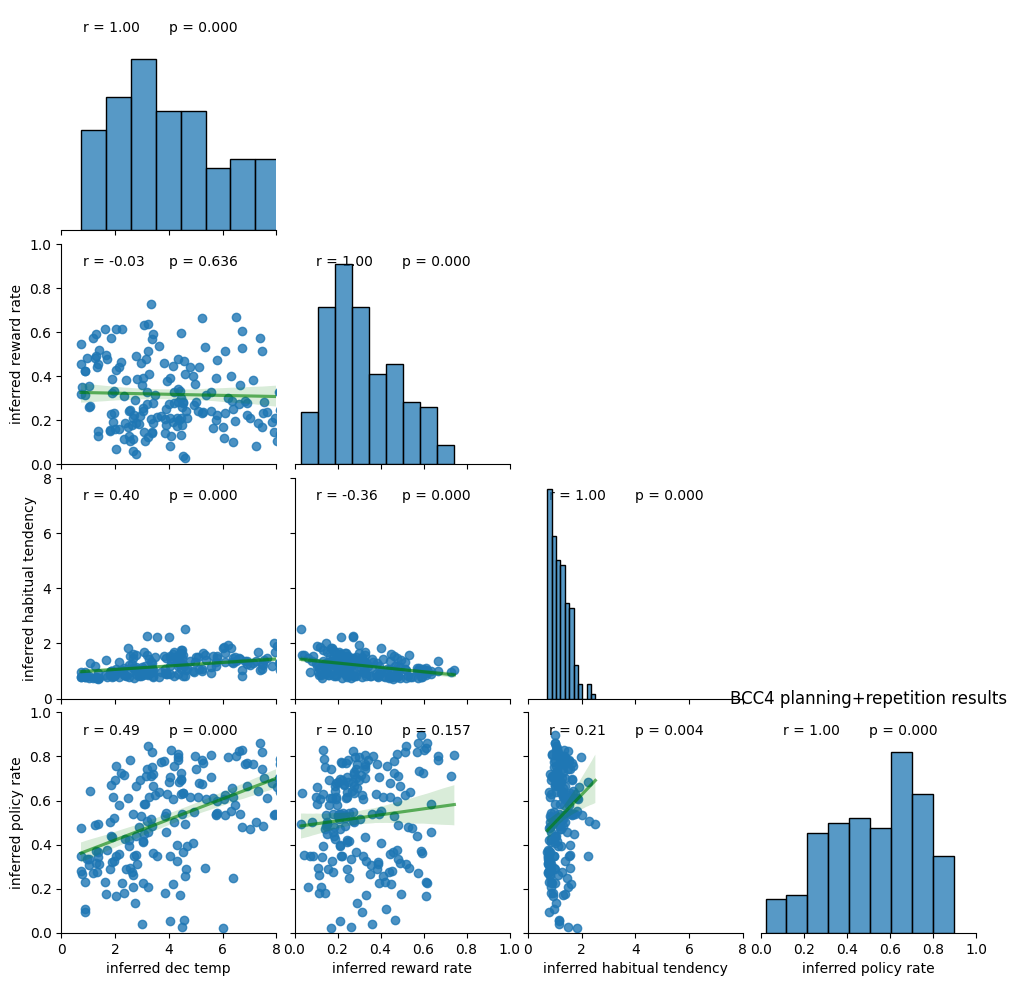

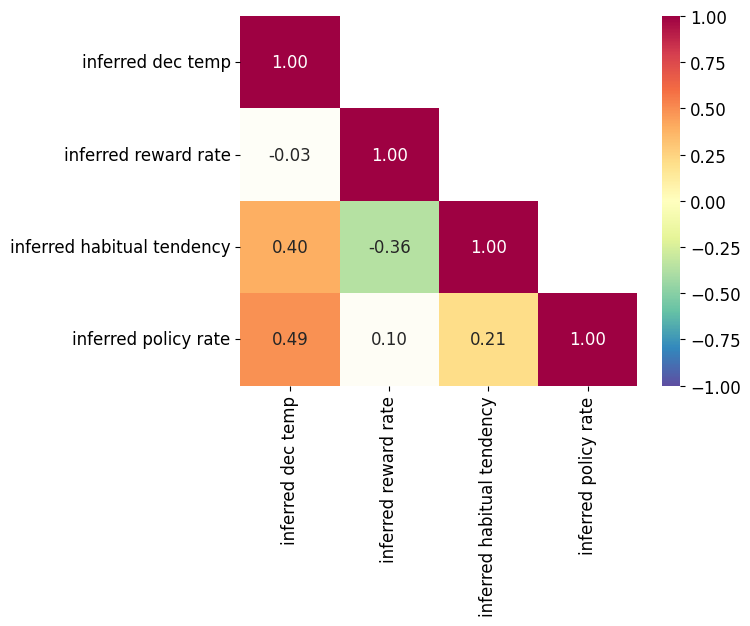

In [14]:
# BCC4 planning repetition analysis

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC4_p_r_param_names = param_names.copy()
BCC4_p_r_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC4_p_r_mean_df, BCC4_p_r_sample_df, BCC4_p_r_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC4_p_r_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC4_p_r_params = torch.stack([torch.tensor(BCC4_p_r_mean_df["inferred "+name]) for name in BCC4_p_r_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC4_p_r_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

plot_correlations(BCC4_p_r_mean_df, vars_of_interest, vars_of_interest)


### Load BCC4 planning+cached results, and plot correlations between inferred parameters

BCC_4pars_plan_cached_NO_context
BCC_4pars_plan_cached_NO_context_inference_
4
analyzing 188 data sets
4


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

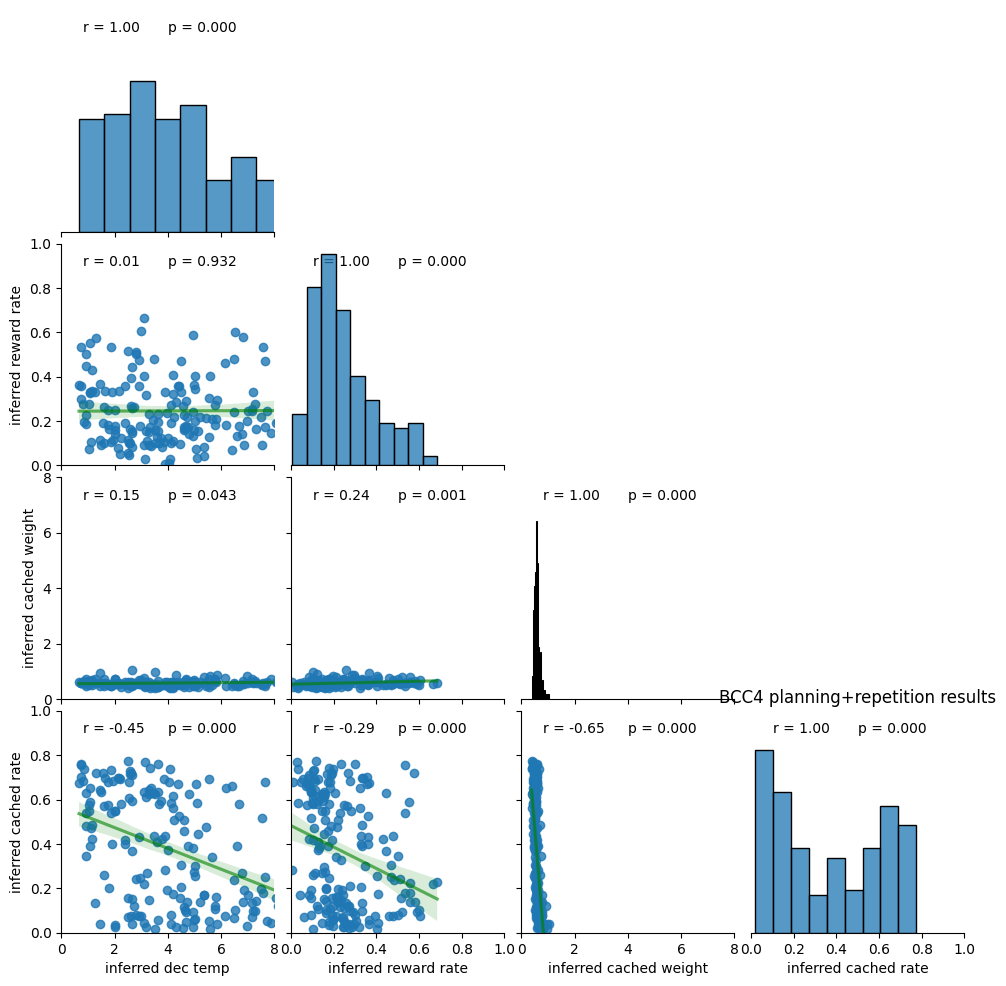

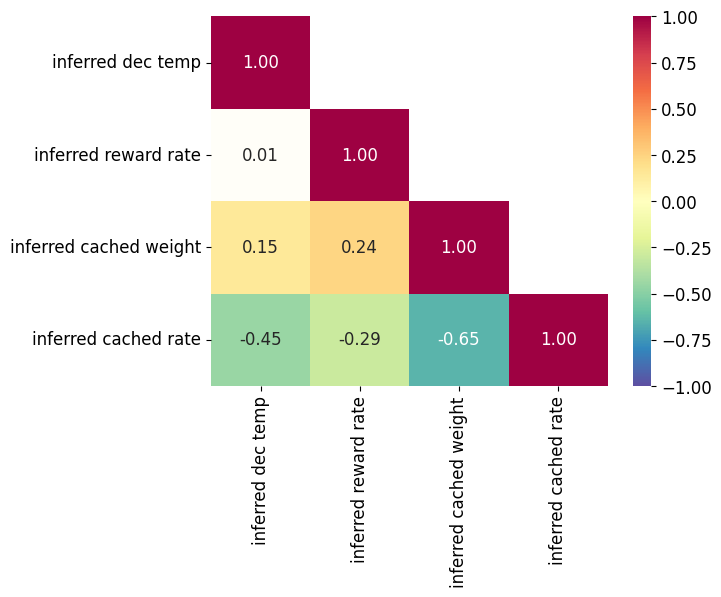

In [15]:
# BCC4 planning cached analysis

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC4_p_c_param_names = param_names.copy()
BCC4_p_c_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC4_p_c_mean_df, BCC4_p_c_sample_df, BCC4_p_c_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC4_p_c_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC4_p_c_params = torch.stack([torch.tensor(BCC4_p_c_mean_df["inferred "+name]) for name in BCC4_p_c_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC4_p_c_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()


plot_correlations(BCC4_p_c_mean_df, vars_of_interest, vars_of_interest)

### Load BCC6results, and plot correlations between inferred parameters

BCC_6pars_plan_habit_weight_cached_NO_context
BCC_6pars_plan_habit_weight_cached_NO_context_inference_
6
analyzing 188 data sets
6


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

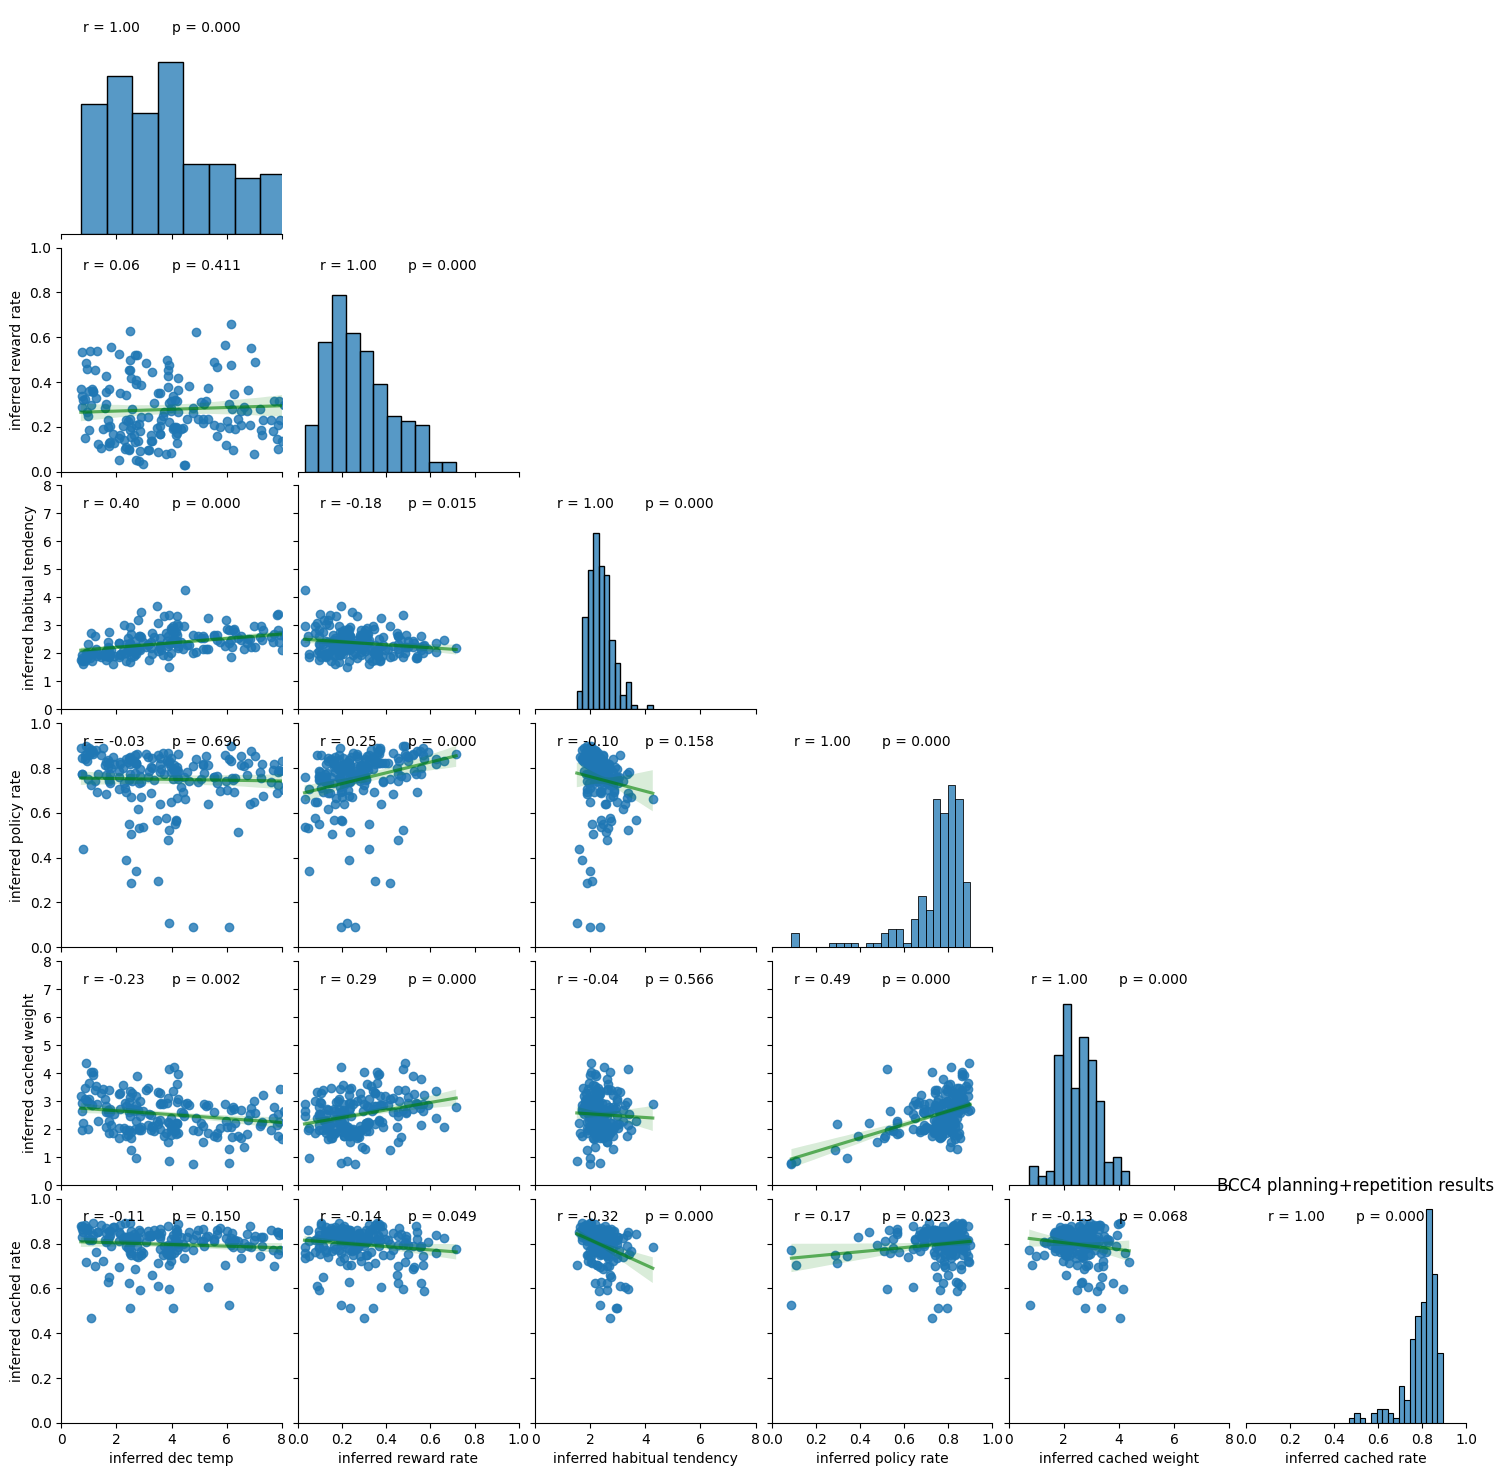

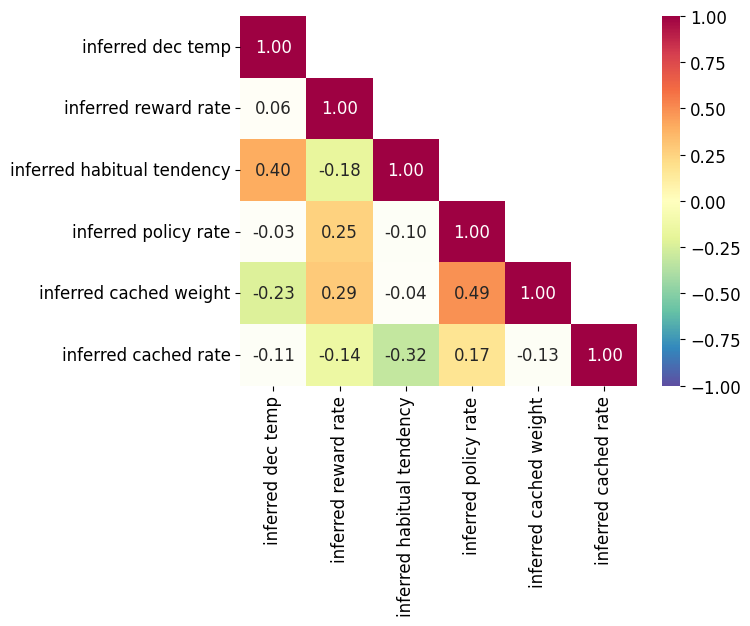

In [16]:
# BCC6 analysis

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC6_param_names = param_names.copy()
BCC6_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC6_mean_df, BCC6_sample_df, BCC6_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC6_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC6_params = torch.stack([torch.tensor(BCC6_mean_df["inferred "+name]) for name in BCC6_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC6_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

plot_correlations(BCC6_mean_df, vars_of_interest, vars_of_interest)

mbmf__inference_
analyzing 188 data sets


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

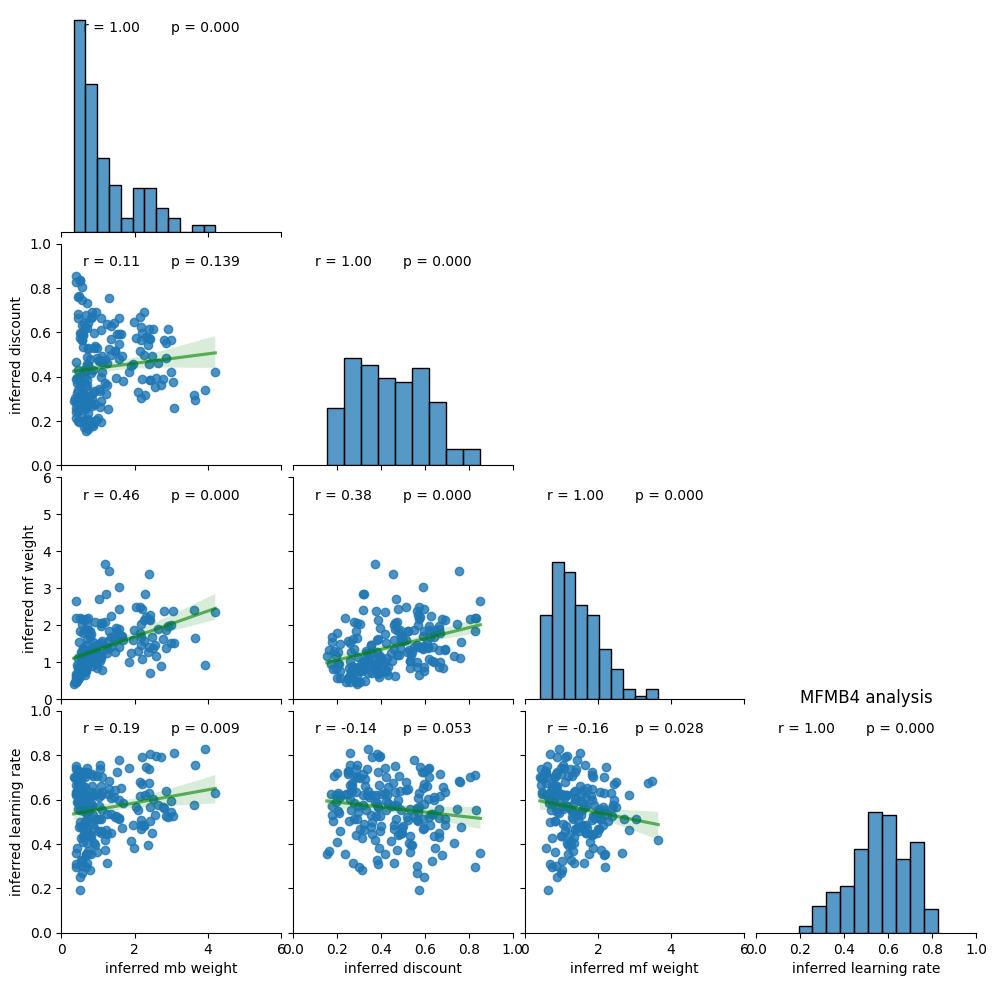

This is inference for the twostage task using the two beta mbmf model(mbmf_) with 188 agents.
The settings are: use p False


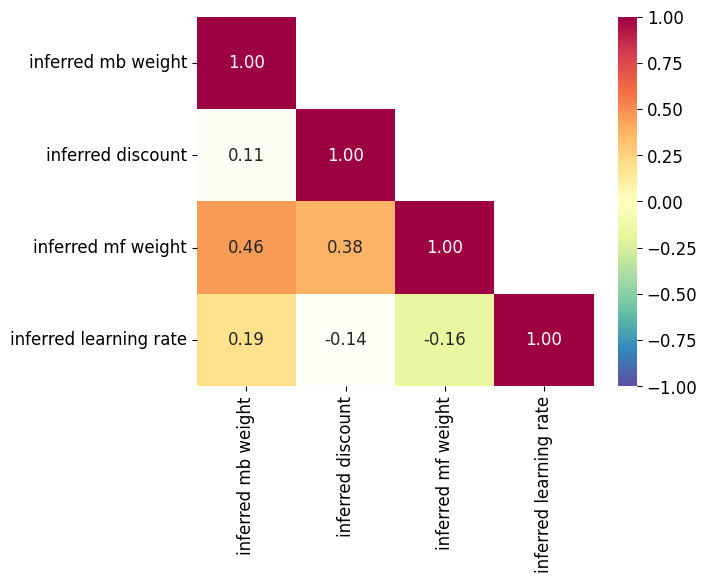

In [17]:
# MFMB4 analysis

# set parameters and their names
learn_prior = False

use_orig = False

use_p = False
restrict_alpha = False
max_dt = 6

n_pars = 4

agnt_str = ""

if use_orig:
    agnt_str += "mbmfOrig_"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    param_ranges = [[0,1], [0,1], [0,8], [0,1]]
else:
    agnt_str += "mbmf_"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

# prepare for saving results
# make base filename and folder string
agent_type = agnt_str

MFMB4_param_names = param_names.copy()
MFMB4_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

MFMB4_mean_df, MFMB4_sample_df, MFMB4_locs_df = load_MFMB_results(use_orig, learn_prior, use_p, restrict_alpha, max_dt, base_dir, global_experiment_parameters, data["valid"], fname_base, num_steps, data, MFMB4_param_names)

MFMB4_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, base_dir, global_experiment_parameters, data["valid"], remove_old=False)

MFMB4_params = torch.stack([torch.tensor(MFMB4_mean_df["inferred "+name]) for name in MFMB4_param_names], dim=-1)

plt.figure()
vars_of_interest = ["inferred "+name for name in MFMB4_param_names]
f = sns.pairplot(data=MFMB4_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(MFMB4_param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("MFMB4 analysis")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()
        
print("This is inference for the twostage task using the "+model_name+"("+agent_type+")"+" with "+str(n_agents)+" agents.")
print("The settings are: use p", use_p)

plot_correlations(MFMB4_mean_df, vars_of_interest, vars_of_interest)

mbmf__prior_inference_
analyzing 188 data sets


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

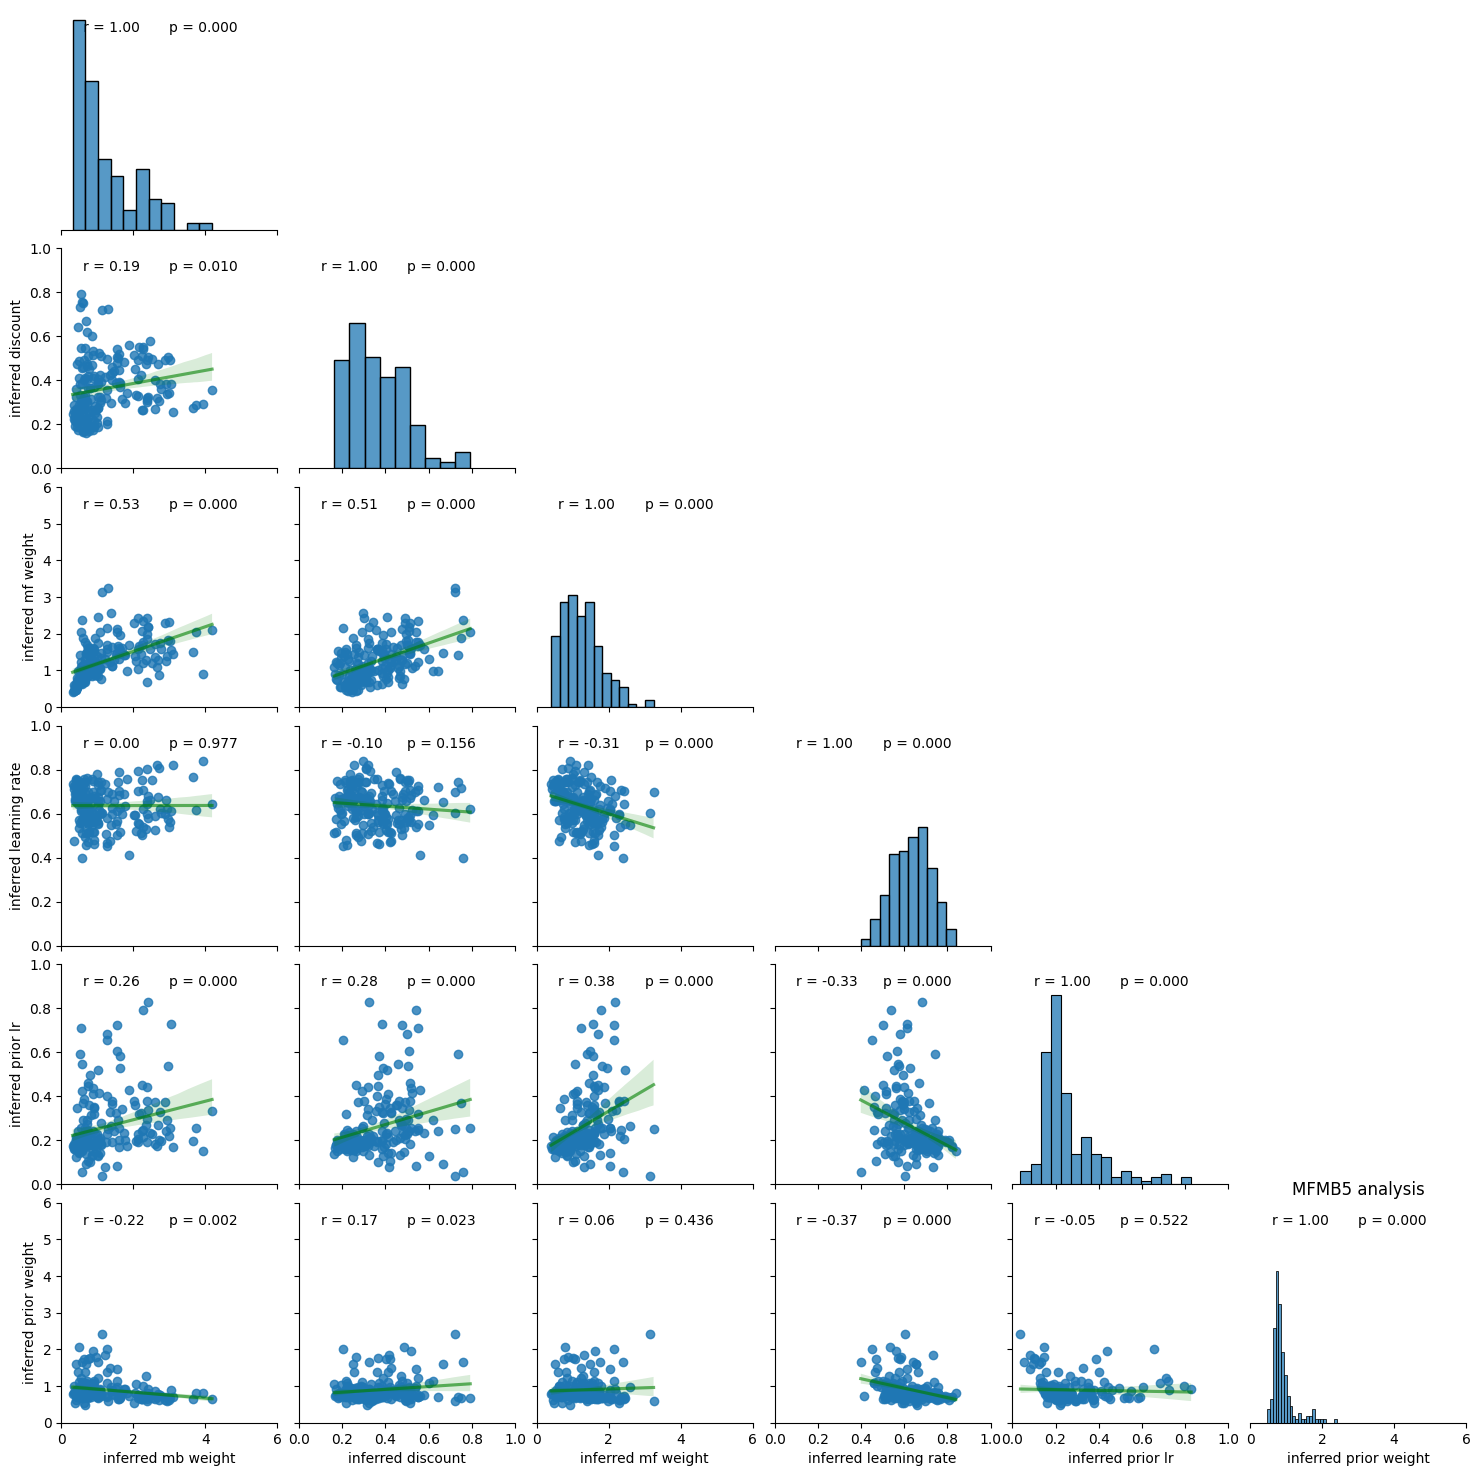

This is inference for the twostage task using the two beta mbmf model(mbmf__prior) with 188 agents.
The settings are: use p False


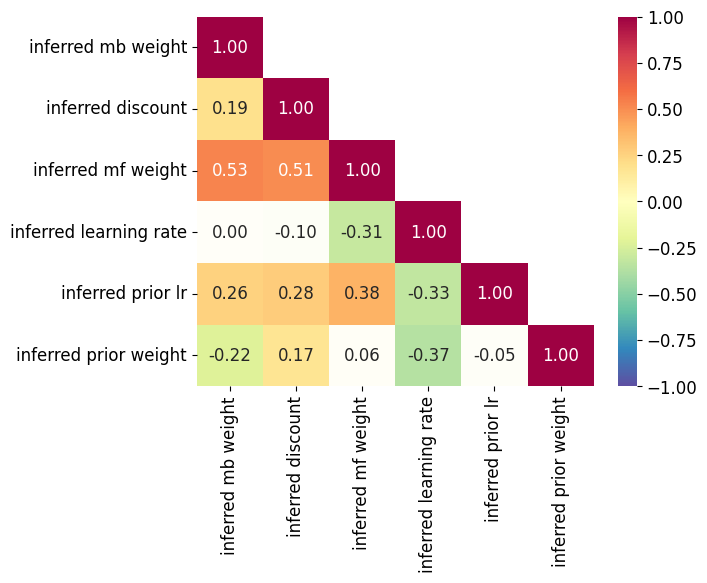

In [18]:
# MFMB6 analysis

# set parameters and their names
learn_prior = True

use_orig = False

use_p = False
restrict_alpha = False
max_dt = 6

n_pars = 4

agnt_str = ""

if use_orig:
    agnt_str += "mbmfOrig_"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    param_ranges = [[0,1], [0,1], [0,8], [0,1]]
else:
    agnt_str += "mbmf_"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

# prepare for saving results
# make base filename and folder string
agent_type = agnt_str

MFMB6_param_names = param_names.copy()
MFMB6_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

MFMB6_mean_df, MFMB6_sample_df, MFMB6_locs_df = load_MFMB_results(use_orig, learn_prior, use_p, restrict_alpha, max_dt, base_dir, global_experiment_parameters, data["valid"], fname_base, num_steps, data, MFMB6_param_names)

MFMB6_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, base_dir, global_experiment_parameters, data["valid"], remove_old=False)

MFMB6_params = torch.stack([torch.tensor(MFMB6_mean_df["inferred "+name]) for name in MFMB6_param_names], dim=-1)

plt.figure()
vars_of_interest = ["inferred "+name for name in MFMB6_param_names]
f = sns.pairplot(data=MFMB6_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(MFMB6_param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("MFMB5 analysis")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()
        
print("This is inference for the twostage task using the "+model_name+"("+agent_type+")"+" with "+str(n_agents)+" agents.")
print("The settings are: use p", use_p)

plot_correlations(MFMB6_mean_df, vars_of_interest, vars_of_interest)

In [19]:
# calculate agent log likelihood using mean params

BCC4_p_r_log_like = -calculate_log_likelihood_mean_param(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_r_lppd = -calculate_lppd(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC4_p_r"]*n_agents})
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_lppd, "type": ["lppd"]*n_agents, "model": ["BCC4_p_r"]*n_agents})])

print("BCC4_p_r log like", BCC4_p_r_log_like.mean())

print("BCC4_p_r lppd", BCC4_p_r_log_like.mean())

gc.collect()

lppd locs torch.Size([50, 188, 4])
BCC4_p_r log like tensor(215.4432)
BCC4_p_r lppd tensor(215.4432)


930

In [20]:
# calculate agent log likelihood using mean params

BCC4_p_c_log_like = -calculate_log_likelihood_mean_param(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_c_lppd = -calculate_lppd(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_lppd, "type": ["lppd"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])

print("BCC4_p_c log like", BCC4_p_c_log_like.mean())

print("BCC4_p_c lppd", BCC4_p_c_log_like.mean())

gc.collect()

lppd locs torch.Size([50, 188, 4])
BCC4_p_c log like tensor(235.9981)
BCC4_p_c lppd tensor(235.9981)


882

In [21]:
# calculate agent log likelihood using mean params

BCC6_log_like = -calculate_log_likelihood_mean_param(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC6_lppd = -calculate_lppd(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_lppd, "type": ["lppd"]*n_agents, "model": ["BCC6"]*n_agents})])

print("BCC6 log like", BCC6_log_like.mean())

print("BCC6 lppd", BCC6_log_like.mean())

gc.collect()

lppd locs torch.Size([50, 188, 6])
BCC6 log like tensor(214.6860)
BCC6 lppd tensor(214.6860)


2430

In [22]:
# calculate agent log likelihood using mean params

MFMB4_log_like = -calculate_log_likelihood_mean_param(data, MFMB4_agent, MFMB4_locs_df, len(MFMB4_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB4_lppd = -calculate_lppd(data, MFMB4_agent, MFMB4_locs_df, len(MFMB4_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB4_log_like, "type": ["log likelihood"]*n_agents, "model": ["MFMB4"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB4_lppd, "type": ["lppd"]*n_agents, "model": ["MFMB4"]*n_agents})])

print("MFMB4 log like", MFMB4_log_like.mean())

gc.collect()

lppd locs torch.Size([50, 188, 4])
MFMB4 log like tensor(213.7767)


0

In [23]:
# calculate agent log likelihood using mean params

MFMB6_log_like = -calculate_log_likelihood_mean_param(data, MFMB6_agent,  MFMB6_locs_df, len(MFMB6_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB6_lppd = -calculate_lppd(data, MFMB6_agent, MFMB6_locs_df, len(MFMB6_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB6_log_like, "type": ["log likelihood"]*n_agents, "model": ["MFMB6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB6_lppd, "type": ["lppd"]*n_agents, "model": ["MFMB6"]*n_agents})])

print("MFMB6 log like", MFMB6_log_like.mean())

gc.collect()

lppd locs torch.Size([50, 188, 6])
MFMB6 log like tensor(214.5104)


0

In [24]:
print(measures_df)

     subject     measure            type     model
0          0  167.925629  log likelihood  BCC4_p_r
1          1  162.967972  log likelihood  BCC4_p_r
2          2  248.646179  log likelihood  BCC4_p_r
3          3  186.611099  log likelihood  BCC4_p_r
4          4  224.943253  log likelihood  BCC4_p_r
..       ...         ...             ...       ...
183      183  281.750427            lppd     MFMB6
184      184  178.186859            lppd     MFMB6
185      185  154.717072            lppd     MFMB6
186      186  208.234314            lppd     MFMB6
187      187  250.985825            lppd     MFMB6

[1880 rows x 4 columns]


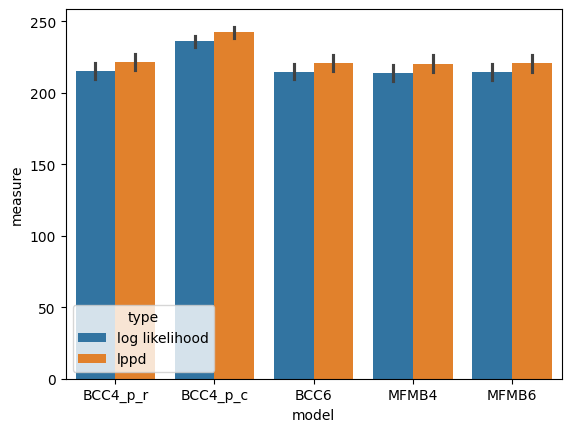

In [25]:
plt.figure()
sns.barplot(data=measures_df, x="model", y="measure", hue="type")
plt.savefig(os.path.join(model_comp_folder, "model_comparison.svg"))
plt.savefig(os.path.join(model_comp_folder, "model_comparison.png"))
plt.show()

### compare predictive accuracies as sanity check

In [26]:
BCC4_p_r_pred_acc = predictive_accuracy_mean_param(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), 
                                               global_experiment_parameters["trials"], global_experiment_parameters["T"])
BCC4_p_r_avg_like, BCC4_p_r_avg_like_from_log = calculate_avg_likelihood_mean_param(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), 
                                                    global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_c_pred_acc = predictive_accuracy_mean_param(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), 
                                               global_experiment_parameters["trials"], global_experiment_parameters["T"])
BCC4_p_c_avg_like, BCC4_p_c_avg_like_from_log = calculate_avg_likelihood_mean_param(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), 
                                                    global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC6_pred_acc = predictive_accuracy_mean_param(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), 
                                               global_experiment_parameters["trials"], global_experiment_parameters["T"])
BCC6_avg_like, BCC6_avg_like_from_log = calculate_avg_likelihood_mean_param(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), 
                                                    global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB4_pred_acc = predictive_accuracy_mean_param(data, MFMB4_agent, MFMB4_locs_df, len(MFMB4_param_names), 
                                                global_experiment_parameters["trials"], global_experiment_parameters["T"])
MFMB4_avg_like, MFMB4_avg_like_from_log = calculate_avg_likelihood_mean_param(data, MFMB4_agent, MFMB4_locs_df, len(MFMB4_param_names), 
                                                     global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB6_pred_acc = predictive_accuracy_mean_param(data, MFMB6_agent, MFMB6_locs_df, len(MFMB6_param_names), 
                                                global_experiment_parameters["trials"], global_experiment_parameters["T"])
MFMB6_avg_like, MFMB6_avg_like_from_log = calculate_avg_likelihood_mean_param(data, MFMB4_agent, MFMB6_locs_df, len(MFMB6_param_names), 
                                                     global_experiment_parameters["trials"], global_experiment_parameters["T"])

In [27]:
avg_measures_df = pd.DataFrame({"type": ["predictive accuracy"]*n_agents, "measure": BCC4_p_r_pred_acc, "model": ["BCC4_p_r"]*n_agents, "subject": list(range(n_agents))})
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["predictive accuracy"]*n_agents, "measure": BCC4_p_c_pred_acc, "model": ["BCC4_p_c"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["predictive accuracy"]*n_agents, "measure": BCC6_pred_acc, "model": ["BCC6"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["predictive accuracy"]*n_agents, "measure": MFMB4_pred_acc, "model": ["MFMB4"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["predictive accuracy"]*n_agents, "measure": MFMB6_pred_acc, "model": ["MFMB6"]*n_agents, "subject": list(range(n_agents))})])

In [28]:
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood"]*n_agents, "measure": BCC4_p_r_avg_like, "model": ["BCC4_p_r"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood"]*n_agents, "measure": BCC4_p_c_avg_like, "model": ["BCC4_p_c"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood"]*n_agents, "measure": BCC6_avg_like, "model": ["BCC6"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood"]*n_agents, "measure": MFMB4_avg_like, "model": ["MFMB4"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood"]*n_agents, "measure": MFMB6_avg_like, "model": ["MFMB6"]*n_agents, "subject": list(range(n_agents))})])

In [29]:
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood from log"]*n_agents, "measure": BCC4_p_r_avg_like_from_log, "model": ["BCC4_p_r"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood from log"]*n_agents, "measure": BCC4_p_c_avg_like_from_log, "model": ["BCC4_p_c"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood from log"]*n_agents, "measure": BCC6_avg_like_from_log, "model": ["BCC6"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood from log"]*n_agents, "measure": MFMB4_avg_like_from_log, "model": ["MFMB4"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood from log"]*n_agents, "measure": MFMB6_avg_like_from_log, "model": ["MFMB6"]*n_agents, "subject": list(range(n_agents))})])

In [30]:
avg_measures_df

,type,measure,model,subject
0,predictive accuracy,0.809278,BCC4_p_r,0
1,predictive accuracy,0.800505,BCC4_p_r,1
2,predictive accuracy,0.619898,BCC4_p_r,2
3,predictive accuracy,0.787879,BCC4_p_r,3
4,predictive accuracy,0.721106,BCC4_p_r,4
...,...,...,...,...
183,average likelihood from log,0.499828,MFMB6,183
184,average likelihood from log,0.618200,MFMB6,184
185,average likelihood from log,0.684302,MFMB6,185
186,average likelihood from log,0.599798,MFMB6,186


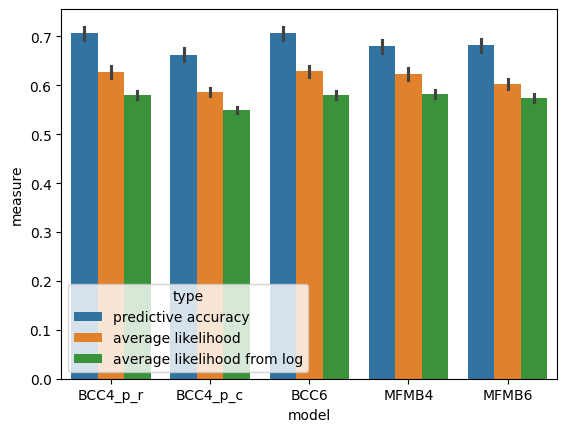

In [31]:
plt.figure()
sns.barplot(data=avg_measures_df, x="model", y="measure", hue="type")
plt.savefig(os.path.join(model_comp_folder, "pred_acc.svg"))
plt.savefig(os.path.join(model_comp_folder, "pred_acc.png"))
plt.show()

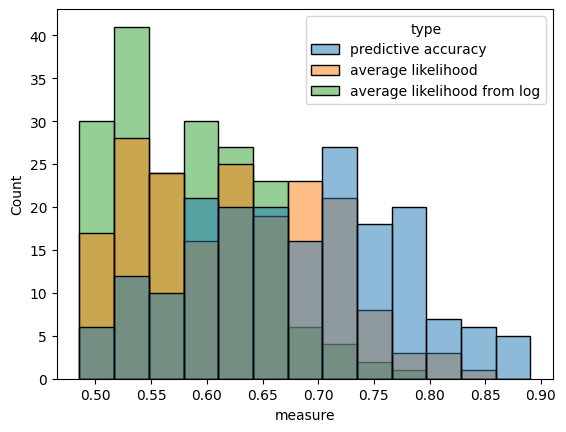

In [32]:
plot_df = avg_measures_df[avg_measures_df["model"]=="MFMB4"]

plt.figure()
sns.histplot(data=plot_df, x="measure", hue="type")
plt.show()

33 participants have random behavior under the model (p>0.01)


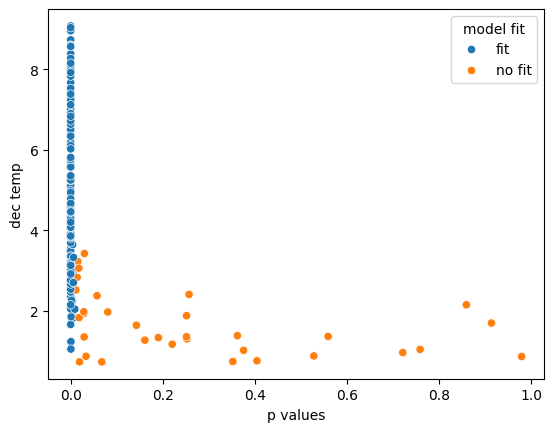

[7, 26, 34, 51, 82, 84, 89, 92, 100, 106, 108, 114, 115, 117, 119, 120, 123, 129, 135, 143, 144, 145, 152, 155, 157, 164, 167, 170, 174, 175, 176, 181, 183]


In [ ]:
from scipy.stats import ttest_1samp

BCC4_p_r_log_like_per_choice = -calculate_log_likelihood_mean_param_per_choice(data, BCC4_p_r_agent, BCC4_p_r_locs_df, 
                                                     len(BCC4_p_r_param_names), global_experiment_parameters["trials"], 
                                                     global_experiment_parameters["T"])

ttest_results = []
BCC4_p_r_didnt_fit = []
p_values = []
didnt_fit_str = []

null_hypothesis = -torch.log(torch.tensor(0.5))
significance_level = 0.01

for n in range(n_agents):
    ttest_results.append(ttest_1samp(BCC4_p_r_log_like_per_choice[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        BCC4_p_r_didnt_fit.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

p_values = torch.tensor(p_values)

print(len(BCC4_p_r_didnt_fit), "participants have random behavior under the BCC4_p_r model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": BCC4_p_r_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC3_1_mean_df["inferred dec temp"])

print(BCC4_p_r_didnt_fit)


52 participants have random behavior under the BCC4_p_c model (p>0.01)


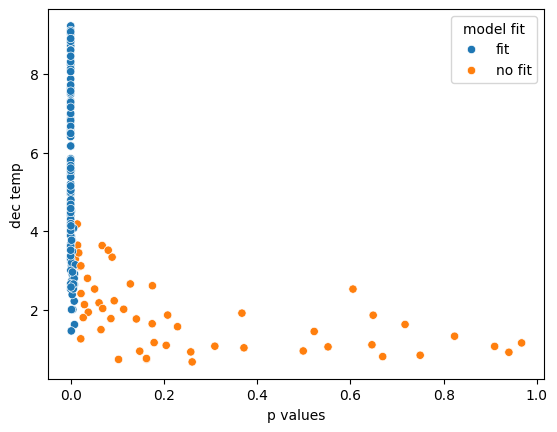

[5, 26, 28, 29, 32, 34, 36, 37, 41, 51, 57, 63, 69, 73, 82, 84, 88, 89, 92, 97, 100, 106, 107, 108, 114, 115, 117, 119, 120, 123, 125, 127, 128, 129, 140, 143, 144, 145, 150, 152, 155, 157, 163, 166, 167, 170, 174, 175, 176, 181, 183, 187]


In [ ]:
from scipy.stats import ttest_1samp

BCC4_p_c_log_like_per_choice = -calculate_log_likelihood_mean_param_per_choice(data, BCC4_p_c_agent, BCC4_p_c_locs_df, 
                                                     len(BCC4_p_c_param_names), global_experiment_parameters["trials"], 
                                                     global_experiment_parameters["T"])

ttest_results = []
BCC4_p_c_didnt_fit = []
p_values = []
didnt_fit_str = []

for n in range(n_agents):
    ttest_results.append(ttest_1samp(BCC4_p_c_log_like_per_choice[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        BCC4_p_c_didnt_fit.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

p_values = torch.tensor(p_values)

print(len(BCC4_p_c_didnt_fit), "participants have random behavior under the BCC4_p_c model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": BCC4_p_c_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC3_1_mean_df["inferred dec temp"])

print(BCC4_p_c_didnt_fit)


28 participants have random behavior under the BCC6 model (p>0.01)


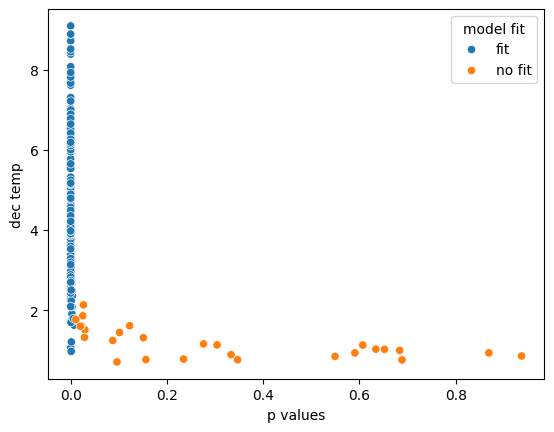

[7, 26, 34, 51, 82, 84, 89, 92, 100, 106, 108, 114, 119, 123, 128, 129, 143, 144, 152, 155, 157, 167, 170, 174, 175, 176, 181, 183]


In [ ]:
from scipy.stats import ttest_1samp

BCC6_log_like_per_choice = -calculate_log_likelihood_mean_param_per_choice(data, BCC6_agent, BCC6_locs_df, 
                                                     len(BCC6_param_names), global_experiment_parameters["trials"], 
                                                     global_experiment_parameters["T"])

ttest_results = []
BCC6_didnt_fit = []
p_values = []
didnt_fit_str = []

for n in range(n_agents):
    ttest_results.append(ttest_1samp(BCC6_log_like_per_choice[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        BCC6_didnt_fit.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

p_values = torch.tensor(p_values)

print(len(BCC6_didnt_fit), "participants have random behavior under the BCC6 model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": BCC6_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC3_1_mean_df["inferred dec temp"])

print(BCC6_didnt_fit)


29 participants have random behavior under the MFMB4 model (p>0.01)


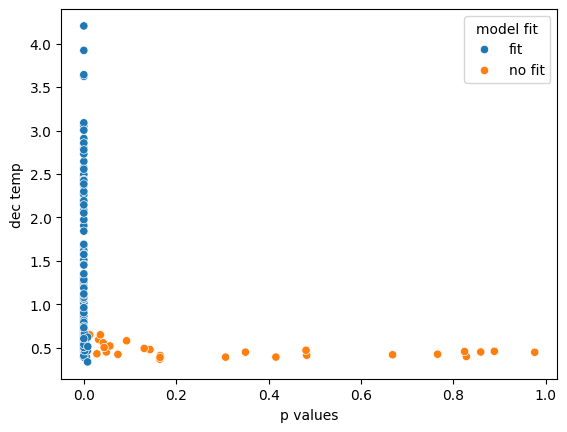

[7, 26, 34, 41, 51, 82, 84, 89, 92, 100, 106, 108, 114, 115, 119, 120, 123, 128, 143, 144, 145, 152, 155, 157, 164, 167, 170, 175, 183]


In [42]:
from scipy.stats import ttest_1samp

MFMB4_log_like_per_choice = -calculate_log_likelihood_mean_param_per_choice(data, MFMB4_agent, MFMB4_locs_df, 
                                                     len(MFMB4_param_names), global_experiment_parameters["trials"], 
                                                     global_experiment_parameters["T"])

ttest_results = []
MFMB4_didnt_fit = []
p_values = []
didnt_fit_str = []

for n in range(n_agents):
    ttest_results.append(ttest_1samp(MFMB4_log_like_per_choice[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        MFMB4_didnt_fit.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

p_values = torch.tensor(p_values)

print(len(MFMB4_didnt_fit), "participants have random behavior under the MFMB4 model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": MFMB4_mean_df["inferred mb weight"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC3_1_mean_df["inferred dec temp"])

print(MFMB4_didnt_fit)


34 participants have random behavior under the MFMB6 model (p>0.01)


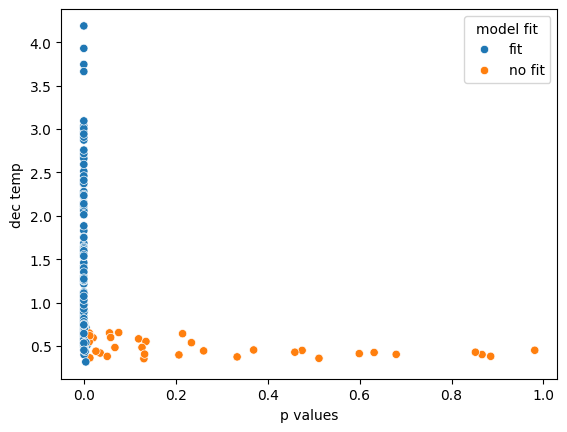

[2, 7, 20, 26, 34, 41, 44, 51, 82, 84, 89, 92, 106, 107, 108, 114, 115, 117, 119, 120, 123, 143, 144, 145, 152, 155, 157, 162, 164, 167, 170, 175, 176, 183]


In [43]:
from scipy.stats import ttest_1samp

MFMB6_log_like_per_choice = -calculate_log_likelihood_mean_param_per_choice(data, MFMB6_agent, MFMB6_locs_df, 
                                                     len(MFMB6_param_names), global_experiment_parameters["trials"], 
                                                     global_experiment_parameters["T"])

ttest_results = []
MFMB6_didnt_fit = []
p_values = []
didnt_fit_str = []

for n in range(n_agents):
    ttest_results.append(ttest_1samp(MFMB6_log_like_per_choice[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        MFMB6_didnt_fit.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

p_values = torch.tensor(p_values)

print(len(MFMB6_didnt_fit), "participants have random behavior under the MFMB6 model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": MFMB6_mean_df["inferred mb weight"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC3_1_mean_df["inferred dec temp"])

print(MFMB6_didnt_fit)


In [45]:
# which participants dont fit in all models?

BCC_didnt_fit = list(set(BCC4_p_r_didnt_fit) & set(BCC4_p_c_didnt_fit) & set(BCC6_didnt_fit))

MFMB_didnt_fit = list(set(MFMB4_didnt_fit) & set(MFMB6_didnt_fit))

all_didnt_fit = list(set(BCC_didnt_fit) & set(MFMB_didnt_fit))

print(len(all_didnt_fit), "didnt fit in all the models:")
print(all_didnt_fit)

with open(non_fit_file, "w") as f:
    json.dump(all_didnt_fit, f)

21 didnt fit in all the models:
[143, 144, 152, 26, 155, 157, 34, 167, 170, 175, 51, 183, 82, 84, 89, 92, 106, 108, 114, 119, 123]
